In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import helper

In [2]:
# @title LogReg from scratch (BCE)
class LogisticRegressionScratchBCE:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.w = None
        self.b = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def predict(self, X):
        z = np.dot(X, self.w) + self.b
        probs = self.sigmoid(z)

        # Return the class with the highest probability
        return np.where(probs >= 0.5, 1, 0)
    
    def predict_proba(self, X):
        z = np.dot(X, self.w) + self.b
        probs = self.sigmoid(z)
        return probs

    def initialize_weights(self, n_features):
        self.w = np.zeros((n_features, 1))  # Init with the same column number as feature
        self.b = 0

    def cost_function(self, h, y):
        m = len(y)
        # reg_term = (0.01 / (2 * m)) * np.sum(self.w ** 2)
        cost = -(1 / m) * np.sum(y * np.log(h + 1e-8) + (1 - y) * np.log(1 - h + 1e-8))

        return cost #+ reg_term

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)  # Ensure y is a column vector
        print(X.shape, y.shape)
        m = len(y)
        n_features = X.shape[1]
        self.initialize_weights(n_features)

        for i in range(self.num_iterations):
            # Forward propagation
            probs = self.predict_proba(X)   # ← FIXED

            # Cost
            error = self.cost_function(probs, y)
            self.losses.append(error)

            # Gradients
            gradient_w = (1 / m) * np.dot(X.T, (probs - y))
            gradient_b = (1 / m) * np.sum(probs - y)

            # Update
            self.w -= self.learning_rate * gradient_w
            self.b -= self.learning_rate * gradient_b

            if i % 100 == 0:
                print(f"Iteration {i}, Cost: {error}")

    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(range(self.num_iterations), self.losses, label='MSE Loss')
        plt.xlabel("Iteration")
        plt.ylabel("Loss (MSE)")
        plt.title("Loss Curve: Logistic Regression (BCE)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [3]:
df = helper.prepare_data()

In [40]:
# X is all pay amount
# X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']]
X = df[['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']].values
y = df['default.payment.next.month'].values

In [49]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X,y = SMOTE(random_state=42).fit_resample(X, y)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Accuracy: 0.7055223219231195
Confusion Matrix:


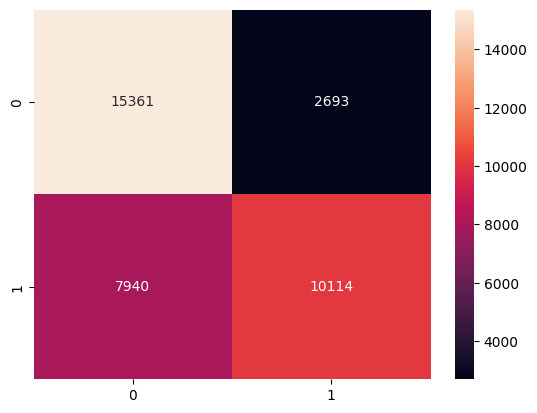

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.85      0.74     18054
           1       0.79      0.56      0.66     18054

    accuracy                           0.71     36108
   macro avg       0.72      0.71      0.70     36108
weighted avg       0.72      0.71      0.70     36108



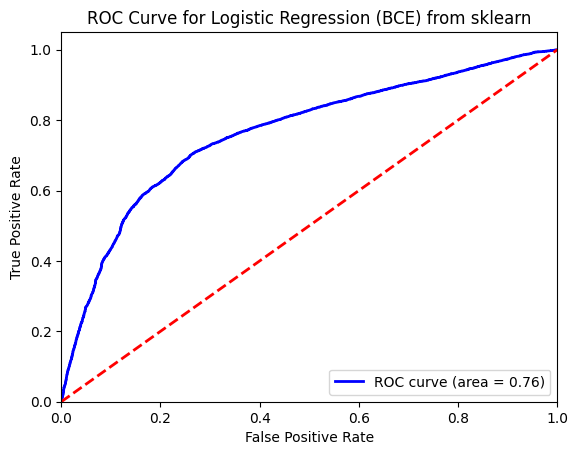

In [47]:
# import and use logistic regression bce from sklearn
model = LogisticRegression(solver='lbfgs')
model.fit(X, y)
y_pred = model.predict(X)
y_pred_proba = model.predict_proba(X)[:, 1]
helper.evaluate_model(y, y_pred)
helper.plot_roc_curve(y, y_pred_proba, title="Logistic Regression (BCE) from sklearn")


Accuracy: 0.7186374965383551
Confusion Matrix:


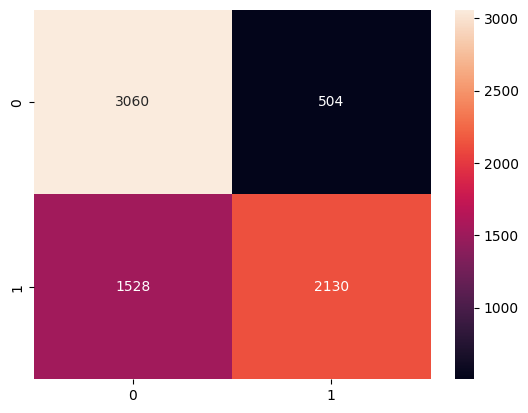

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.86      0.75      3564
           1       0.81      0.58      0.68      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.72      0.71      7222
weighted avg       0.74      0.72      0.71      7222



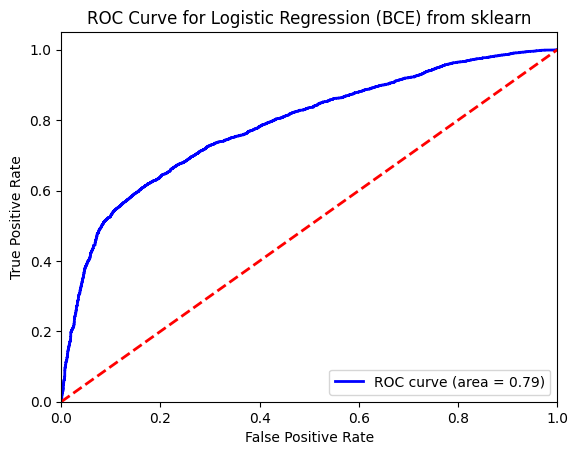

In [50]:
model = LogisticRegression(solver='lbfgs')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
helper.evaluate_model(y_test, y_pred)
helper.plot_roc_curve(y_test, y_pred_proba, title="Logistic Regression (BCE) from sklearn")

(28886, 23) (28886, 1)
Iteration 0, Cost: 0.6931471605599453
Iteration 100, Cost: 0.6069134861938109
Iteration 200, Cost: 0.585709458155063
Iteration 300, Cost: 0.5773630702655327
Iteration 400, Cost: 0.57311075617716
Iteration 500, Cost: 0.5705229434808127
Iteration 600, Cost: 0.5687471060307003
Iteration 700, Cost: 0.5674310459756915
Iteration 800, Cost: 0.5664074461278289
Iteration 900, Cost: 0.565586158307163
Accuracy: 0.7227914705067848
Confusion Matrix:


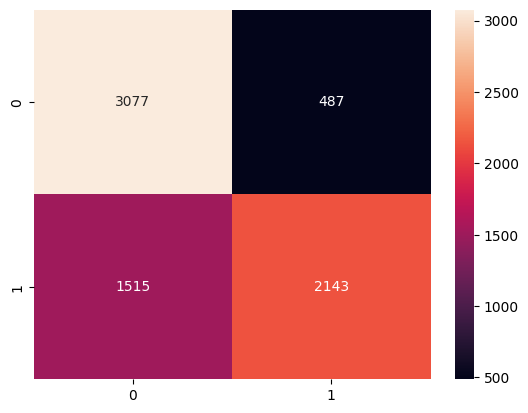

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.86      0.75      3564
           1       0.81      0.59      0.68      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.72      0.72      7222
weighted avg       0.74      0.72      0.72      7222



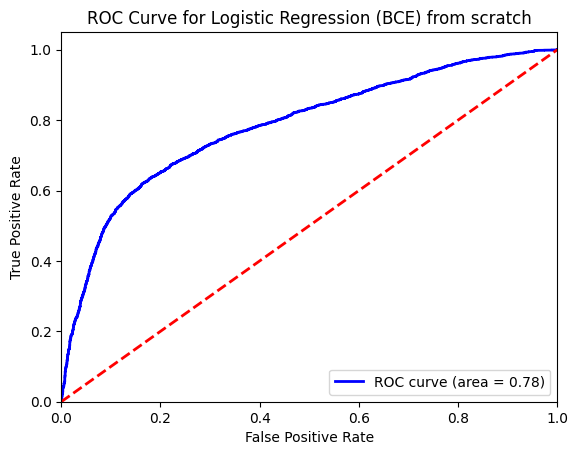

In [51]:
bce_model = LogisticRegressionScratchBCE(learning_rate=0.01, num_iterations=1000)
bce_model.fit(X_train, y_train)
y_pred_bce = bce_model.predict(X_test)
y_pred_proba_bce = bce_model.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred_bce)
helper.plot_roc_curve(y_test, y_pred_proba_bce, title="Logistic Regression (BCE) from scratch")

### All feature

In [47]:
X = df.drop('default.payment.next.month', axis=1).values
y = df['default.payment.next.month'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)
X,y = SMOTE(random_state=42).fit_resample(X, y)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

(28886, 23) (28886, 1)
Iteration 0, Cost: 0.6931471605599453
Iteration 100, Cost: 0.6003098717609343
Iteration 200, Cost: 0.5823002527831954
Iteration 300, Cost: 0.5752364993579862
Iteration 400, Cost: 0.5714836446499145
Iteration 500, Cost: 0.5691029129368188
Iteration 600, Cost: 0.5674244302312645
Iteration 700, Cost: 0.5661661744242458
Iteration 800, Cost: 0.5651883971376582
Iteration 900, Cost: 0.5644114273743882
Accuracy: 0.7230684021046802
Confusion Matrix:


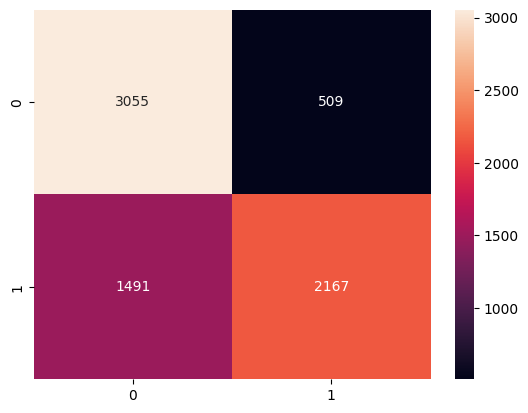

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.86      0.75      3564
           1       0.81      0.59      0.68      3658

    accuracy                           0.72      7222
   macro avg       0.74      0.72      0.72      7222
weighted avg       0.74      0.72      0.72      7222



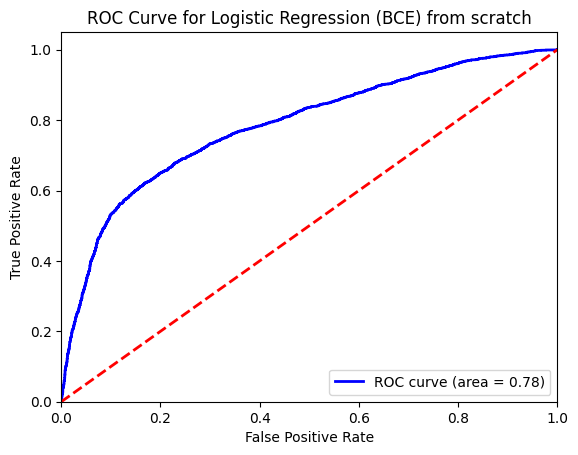

In [48]:
bce_model = LogisticRegressionScratchBCE(learning_rate=0.01, num_iterations=1000)
bce_model.fit(X_train, y_train)
y_pred_bce = bce_model.predict(X_test)
y_pred_proba_bce = bce_model.predict_proba(X_test)
helper.evaluate_model(y_test, y_pred_bce)
helper.plot_roc_curve(y_test, y_pred_proba_bce, title="Logistic Regression (BCE) from scratch")